In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import sys
import localSettings as ls
import math
print(ls.main_path)
import load_data_run123
import plotter_alex
import importlib
importlib.reload(plotter_alex)
import uproot
import matplotlib.pylab as pylab
import numpy as np
import math
from sklearn.model_selection import train_test_split
import pickle
import xgboost as xgb
import nue_booster 
importlib.reload(nue_booster)
import awkward
from matplotlib import gridspec
from collections import defaultdict
import ROOT
from ROOT import TFile
from ROOT import TCanvas, TFile, TProfile, TNtuple, TH1F, TH2F
from ROOT import gROOT, gBenchmark, gRandom, gSystem
import csv

/home/alex/NuMI/PELEE/
Welcome to JupyROOT 6.24/02


In [2]:
import NuMIGeoWeights
import importlib
importlib.reload(NuMIGeoWeights)
numiBeamlineGeoWeights = NuMIGeoWeights.NuMIGeoWeights()

In [3]:
params = {
    'axes.labelsize': 'x-large',
    'axes.titlesize': 'x-large',
    'xtick.labelsize': 'x-large',
    'ytick.labelsize': 'x-large'
}
pylab.rcParams.update(params)

In [4]:
isRun3 = True

#to use both Run1 and Run3. Can only use this for the end
isCombined = True

ending = "Mar25"

In [5]:
###########################################################

In [5]:
# Name of the TTree in the PeLEE Ntuples
tree = "NeutrinoSelectionFilter"

#full sample, re-weighted flux
if isRun3 == False and isCombined == False:
    NU   = '/numi_run1_nu_overlay_fhc_reweightedPPFX'    +ls.APPEND #newTune
elif isRun3 == True  and isCombined == False:
    NU   = '/numi_nu_pelee_ntuples_run3_rhc_g4.10.4_full'    +ls.APPEND 

#actually fetch datasets
if isCombined == False:
    numu_mc  = uproot.open(ls.ntuple_path+NU+".root")[ls.fold][tree]


# Define a list that contains the data sets
if isCombined == False:
    uproot_v = [numu_mc]

numu_variables = [
        "nu_pdg", "slpdg", "backtracked_pdg",
        "category", "ccnc", "swtrig_pre",
        "run","sub","evt",
        "CosmicIP","CosmicDirAll3D","CosmicIPAll3D",
        "contained_fraction",
        "trk_llr_pid_score_v",
        "_opfilter_pe_beam", "_opfilter_pe_veto",
        "reco_nu_vtx_sce_x","reco_nu_vtx_sce_y","reco_nu_vtx_sce_z",
        "nmuon", "n_showers_contained", "shr_tkfit_dedx_Y", "tksh_distance",
        "shr_energy_tot_cali", "trk_energy_tot",
        "nproton", "mc_pdg", "slnunhits", "slnhits", "true_e_visible",
        "npi0","npion","pion_e","muon_e","pi0truth_elec_etot",
        "pi0_e", "evnunhits", "nslice", "interaction",
        "slclustfrac", "reco_nu_vtx_x", "reco_nu_vtx_y", "reco_nu_vtx_z",
        "topological_score", "elec_e", "proton_e",
        "isVtxInFiducial", "trk_sce_end_x_v", "trk_sce_end_y_v", "trk_sce_end_z_v", "trk_sce_start_x_v",
        "trk_theta", "trk_phi", "trk_energy_muon", "trk_range_muon_mom_v", "trk_mcs_muon_mom_v"
    ]


# These are examples of variables present in MC samples only
numu_varMC = ["nu_e", "true_pt","true_pt_visible","true_p","true_p_visible","true_nu_vtx_t","true_nu_vtx_x","true_nu_vtx_y","true_nu_vtx_z","true_nu_vtx_sce_x","true_nu_vtx_sce_y","true_nu_vtx_sce_z\
","true_nu_px","true_nu_py","true_nu_pz", "theta", "mc_pdg", "mc_px", "mc_py", "mc_pz"]


#make the list unique (sometimes you repeat the variable name in the list, this takes care of that)
numu_variables = list(set(numu_variables))
print(numu_variables)



# These weights are needed to correctly calculate the CV for the MC    
WEIGHTS     = ["weightSpline","weightTune","weightSplineTimesTune","ppfx_cv"]
# These weights are needed to calculate the Flux, GENIE and Geant4 Systematics. 
# For NuMI weightsFlux should always be 1 (cause that's relevant for BNB).
SYSTEMATICS = ['weightsFlux','weightsGenie','weightsReint'] 
PPFX        = ['weightsPPFX'] 



WEIGHTSLEE = ["weightSpline","weightTune","weightSplineTimesTune", "leeweight"]
MCFVARS    = ["mcf_nu_e","mcf_lep_e","mcf_actvol","mcf_nmm","mcf_nmp","mcf_nem","mcf_nep","mcf_np0","mcf_npp",
              "mcf_npm","mcf_mcshr_elec_etot","mcf_pass_ccpi0","mcf_pass_ncpi0",
              "mcf_pass_ccnopi","mcf_pass_ncnopi","mcf_pass_cccpi","mcf_pass_nccpi"]

['slnunhits', 'CosmicIP', 'npion', 'trk_phi', 'n_showers_contained', 'reco_nu_vtx_sce_x', 'trk_energy_muon', 'trk_theta', 'topological_score', 'CosmicDirAll3D', 'nslice', 'slnhits', 'CosmicIPAll3D', 'trk_llr_pid_score_v', 'ccnc', 'trk_sce_end_x_v', 'trk_sce_start_x_v', '_opfilter_pe_beam', 'tksh_distance', 'isVtxInFiducial', 'category', 'interaction', 'nmuon', 'trk_mcs_muon_mom_v', 'muon_e', 'pi0_e', 'trk_range_muon_mom_v', 'reco_nu_vtx_y', 'shr_energy_tot_cali', 'swtrig_pre', 'true_e_visible', 'pion_e', 'elec_e', 'npi0', 'trk_sce_end_y_v', 'pi0truth_elec_etot', 'reco_nu_vtx_sce_y', 'evt', 'reco_nu_vtx_z', 'trk_sce_end_z_v', 'reco_nu_vtx_sce_z', 'sub', 'backtracked_pdg', 'proton_e', 'trk_energy_tot', 'slclustfrac', 'nproton', 'nu_pdg', 'slpdg', 'run', '_opfilter_pe_veto', 'contained_fraction', 'mc_pdg', 'evnunhits', 'reco_nu_vtx_x', 'shr_tkfit_dedx_Y']


In [6]:
import time
s = time.time()

import pandas as pandas

mc_var   = numu_variables + WEIGHTS + MCFVARS + SYSTEMATICS + PPFX + numu_varMC
var_v    = [mc_var]


if isCombined == False:
    uproot_v = [numu_mc]
    
    for ii, CV in enumerate(uproot_v):
        CVDF  = CV.pandas.df(var_v[ii], flatten=False)
        load_data_run123.process_uproot_numu(CV,CVDF)
        if ii == 0:
            numu_mc = CVDF     

s2 = time.time()

print("runtime = ", s2-s)

trk_llr_pid_v  [[] [-3.4028235e+38 -0.53329843 -0.37919396 -0.16951479] [0.8026565 0.122559376] ... [] [] [0.9814954 0.88408315 0.2547488]]
trk_score_v  [[] [-1.0 0.8406699 0.89783436 0.8321769] [0.91174966 0.013312283] ... [] [] [1.0 0.0007528009 0.027561903]]


/home/alex/miniconda3/envs/vintageXgboostVintageUprootEnv/lib/python3.8/site-packages/awkward/array/jagged.py:1043: RuntimeWarning: overflow encountered in power
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/alex/miniconda3/envs/vintageXgboostVintageUprootEnv/lib/python3.8/site-packages/awkward/array/jagged.py:1043: RuntimeWarning: overflow encountered in true_divide
  result = getattr(ufunc, method)(*inputs, **kwargs)


updated proton mask test
runtime =  821.2812922000885


# Weights

In [7]:
df_v = [numu_mc]
for i,df in enumerate(df_v):
    df[ 'currentweightsafe' ] = df['weightSplineTimesTune']
    df[ 'currentweight' ] = df['weightSplineTimesTune']

In [8]:

s = time.time()

df_v = [numu_mc]
for i,df in enumerate(df_v):
    df.loc[ df['weightTune'] <= 0, 'weightTune' ] = 1.
    df.loc[ df['weightTune'] == np.inf, 'weightTune' ] = 1.
    df.loc[ df['weightTune'] > 100, 'weightTune' ] = 1.
    df.loc[ np.isnan(df['weightTune']) == True, 'weightTune' ] = 1.    
    
    df.loc[ df['weightSplineTimesTune'] <= 0, 'weightSplineTimesTune' ] = 1.
    df.loc[ df['weightSplineTimesTune'] == np.inf, 'weightSplineTimesTune' ] = 1.
    df.loc[ df['weightSplineTimesTune'] > 100, 'weightSplineTimesTune' ] = 1.
    df.loc[ np.isnan(df['weightSplineTimesTune']) == True, 'weightSplineTimesTune' ] = 1. 
    df[ 'weightSplineTimesTuneTimesPPFX' ] = df[ 'weightSplineTimesTune' ]*df['ppfx_cv']
    
    df.loc[ df['weightSpline'] <= 0, 'weightSpline' ] = 1.
    df.loc[ df['weightSpline'] == np.inf, 'weightSpline' ] = 1.
    df.loc[ df['weightSpline'] > 100, 'weightSpline' ] = 1.
    df.loc[ np.isnan(df['weightSpline']) == True, 'weightSpline' ] = 1. 
    df[ 'weightSplineTimesPPFX' ]  = df[ 'weightSpline' ]*df['ppfx_cv']
    
    
s2 = time.time()
print("runtime = ", s2-s)

runtime =  0.22077083587646484


In [9]:
df_v = [numu_mc]
for i,df in enumerate(df_v):
    df[ 'currentweight' ] = df['weightSplineTimesTuneTimesPPFX']
    df[ 'currentweightsafe' ] = df['weightSplineTimesTuneTimesPPFX']
    df[ 'currentweightsafe2' ] = df['weightSplineTimesTuneTimesPPFX']
    df[ 'currentweight2' ] = df['weightSplineTimesTuneTimesPPFX']

In [10]:
df_v = [numu_mc]
scaleFlat = 0
for i,df in enumerate(df_v):
    if scaleFlat == 1:
        df['weightSplineTimesTuneTimesPPFX'] = df[ 'currentweight' ] 
        df.loc[ df['npi0'] > 0, 'weightSplineTimesTuneTimesPPFX' ] =  (df['weightSplineTimesTuneTimesPPFX'] * 0.759)
    elif scaleFlat == 2:
        df['weightSplineTimesTune'] = df[ 'currentweight' ] 
        pi0emax = 0.6
        df.loc[ (df['pi0_e'] > 0.1) & (df['pi0_e'] < pi0emax) , 'weightSplineTimesTuneTimesPPFX'] = df['weightSplineTimesTuneTimesPPFX']*(1.-0.4*df['pi0_e'])
        df.loc[ (df['pi0_e'] > 0.1) & (df['pi0_e'] >= pi0emax), 'weightSplineTimesTuneTimesPPFX'] = df['weightSplineTimesTuneTimesPPFX']*(1.-0.4*pi0emax)
    elif scaleFlat == 0:
        df['weightSplineTimesTuneTimesPPFX'] = df[ 'currentweight' ]

In [11]:
df_v = [numu_mc]
for i,df in enumerate(df_v):
    df[ 'noW' ] = 1

# Adding variables

In [12]:
df_v = [numu_mc]
for i,df in enumerate(df_v):  
    df["bnbdata"] = np.zeros_like(df["isVtxInFiducial"])
    df["extdata"] = np.zeros_like(df["isVtxInFiducial"])

In [13]:
numu_mc.query("nu_e > 0 and nu_pdg==14 and ccnc==0 and nproton>0 and npion==0 \
and npi0==0 and 10 <= true_nu_vtx_x and true_nu_vtx_x <= 246 and -106 <= true_nu_vtx_y \
and true_nu_vtx_y <= 106 and 10 <= true_nu_vtx_z and true_nu_vtx_z <= 1026", inplace=True)

In [14]:
def energyToPxyz(energy, theta, phi, mask, mass = 0.93827208816):
    if all(~mask):
        return (0.,0.,0.)
    energy = energy.copy()[mask]
    theta  = theta.copy()[mask]
    phi    = phi.copy()[mask]
    
    p  = np.sqrt((energy+mass)*(energy+mass) - mass*mass)
    pz = p*np.cos(theta)
    px = p*np.sin(theta)*np.cos(phi)
    py = p*np.sin(theta)*np.sin(phi)
    return( px.sum(), py.sum(), pz.sum())



for i,df in enumerate(df_v):
    up = uproot_v[i]
    trk_theta_proton_v  = up.array('trk_theta_v')
    trk_phi_proton_v    = up.array('trk_phi_v')
    trk_energy_proton_v = up.array('trk_energy_proton_v')
    ############ muon part
    mu_px_v            = up.array('shr_px')
    mu_py_v            = up.array('shr_py')
    mu_pz_v            = up.array('shr_pz')
    pt_v                = up.array('pt')
    trk_score_v         = up.array('trk_score_v')    
    trk_llr_pid_v       = up.array('trk_llr_pid_score_v')
    

    trk_mask      = (trk_score_v>0.5)
    proton_mask_v = (trk_score_v>0.5)&(trk_llr_pid_v < 0.)
    sillyCount = 0
    listPx,listPy,listPz = [],[],[]
    
    for mask, theta_t, phi_t, energy_t,proton_mask_v_t,sx,sy,sz,pttt  in zip(proton_mask_v, trk_theta_proton_v,trk_phi_proton_v, trk_energy_proton_v,proton_mask_v, mu_px_v,mu_py_v,mu_pz_v,pt_v):
        tempMom = energyToPxyz(energy_t,theta_t,phi_t,proton_mask_v_t) 
        nu_reco_px = tempMom[0] + sx 
        nu_reco_py = tempMom[1] + sy  
        nu_reco_pz = tempMom[2] + sz  
        listPx.append(nu_reco_px)
        listPy.append(nu_reco_py)
        listPz.append(nu_reco_pz)

/tmp/ipykernel_5472/3373323908.py:8: RuntimeWarning: overflow encountered in multiply
  p  = np.sqrt((energy+mass)*(energy+mass) - mass*mass)


In [15]:
#defs will go here

from scipy.spatial.transform import Rotation as R
from numpy import arccos, array
from numpy.linalg import norm

# Note: returns angle in radians
def theta(v, w): return arccos(v.dot(w)/(norm(v)*norm(w)))* 180 / 3.1415926

def GetNuMIAngle( px,  py,  pz):
    r = R.from_matrix([[0.92103853804025681562   , 0.022713504803924120662, 0.38880857519374290021  ],
                       [4.6254001262154668408e-05, 0.99829162468141474651 , -0.058427989452906302359],
                       [-0.38947144863934973769  , 0.053832413938664107345, 0.91946400794392302291  ]])  
    r = r.inv()
    beamCoords = r.apply([px,  py,  pz])
    beamDir    = [0,0,1]
    return theta(beamCoords,beamDir)

def GetNuMIAnglePol( phiBNB,  thetaBNB):
    px = math.sin(thetaBNB)*math.cos(phiBNB)
    py = math.sin(thetaBNB)*math.sin(phiBNB)
    pz = math.cos(thetaBNB)
    return GetNuMIAngle( px,  py,  pz)

In [16]:
def vectorFromNuMITarget(vtxX,  vtxY, vtxZ):
    numiTarget      = np.array([-31387.58422, -3316.402543, -60100.2414])
    nuInteraction   = np.array([vtxX,  vtxY, vtxZ])
    directionVector = nuInteraction - numiTarget
    return directionVector

def angleFromNuMITarget(vtxX,  vtxY, vtxZ, thetaBNB, phiBNB):
    v1 = vectorFromNuMITarget(vtxX,  vtxY, vtxZ)  
    norm = np.linalg.norm(v1)
    v1 = v1/norm
    v2 = [np.cos(phiBNB)*np.sin(thetaBNB),np.sin(phiBNB)*np.sin(thetaBNB), np.cos(thetaBNB) ]
    dot_product = np.dot(v1, v2)
    angle = np.arccos(dot_product)
    return angle #dot_product # angle*180/3.14159265

angleFromNuMITarget(1,1,1,1.4,3.)

1.8690124908136228

In [17]:
#TRUE VARIABLE
s = time.time()

for i,df in enumerate(df_v):
    df["muon_px"] = df["ccnc"].copy()
    df["muon_py"] = df["ccnc"].copy()
    df["muon_pz"] = df["ccnc"].copy()
    for j, row in df.iterrows():
        pdg_vector = df["mc_pdg"].loc[j][0]
        px_vector = df["mc_px"].loc[j]
        py_vector = df["mc_py"].loc[j]
        pz_vector = df["mc_pz"].loc[j]
        result = np.where(pdg_vector==13)[0]
        if np.size(result):
            df.loc[j, "muon_px"] = px_vector[result][0]
            df.loc[j, "muon_py"] = py_vector[result][0]
            df.loc[j, "muon_pz"] = pz_vector[result][0]   


print("")    
print("==========================")
s2 = time.time()
print("runetime = ", s2-s)


runetime =  885.0960779190063


In [18]:
#TRUE VARIABLE
#in this we use the NEUTRINO VERTEX and the MUON PHI/THETA and will get the ANGLE BETWEEN THEM

for i,df in enumerate(df_v):
    df['targetP']     = np.sqrt(df['muon_px']*df['muon_px'] + df['muon_py']*df['muon_py'] + df['muon_pz']*df['muon_pz'])
    df['targetPt']    = np.sqrt(df['muon_px']*df['muon_px'] + df['muon_py']*df['muon_py'])
    df['targetTheta'] = np.arccos(df['muon_pz']/df['targetP'] )
    df['targetPhi']   = np.arctan2(df['muon_py'],df['muon_px'])
    df['nu_Angle_Numi_Muon'] = df.apply( lambda x: angleFromNuMITarget(x['true_nu_vtx_sce_x'],x['true_nu_vtx_sce_y'],x['true_nu_vtx_sce_z'], x['targetTheta'],x['targetPhi']) , axis=1)
    df['cosNu_Angle_Numi_Muon'] = np.cos(df['nu_Angle_Numi_Muon'])

In [19]:
#RECO VARIABLE
#in this we use the NEUTRINO VERTEX and the MUON PHI/THETA and will get the ANGLE BETWEEN THEM

for i,df in enumerate(df_v):
    df['nu_Angle_Numi_Muon_Reco'] = df.apply( lambda x: angleFromNuMITarget(x['reco_nu_vtx_sce_x'],x['reco_nu_vtx_sce_y'],x['reco_nu_vtx_sce_z'], x['trk_theta'],x['trk_phi']) , axis=1)
    df['cosNu_Angle_Numi_Muon_Reco'] = np.cos(df['nu_Angle_Numi_Muon_Reco'])

# Event Categories

In [20]:
numu_mc   = numu_mc.query('nu_e > 0.')

# Calculate the true neutrino direction off of the NuMI beam, needed for plotting. Seem to be from MC
dfmc_v = [numu_mc]
for i,df in enumerate(dfmc_v):
    df['numi_nu_true_Angle'] = df.apply( lambda x: GetNuMIAngle(x['true_nu_px'],x['true_nu_py'],x['true_nu_pz']) , axis=1)
    df['weightsNuMIGeo']     = df.apply( lambda x: numiBeamlineGeoWeights.calculateGeoWeight(x['nu_pdg'],x['nu_e'],x['numi_nu_true_Angle']) , axis=1)
    

# Selection

In [21]:
df_v = [numu_mc]

for i,df in enumerate(df_v):

    df['is_signal'] = np.where((df.nu_pdg==14) & (df.ccnc==0) & (df.nproton>0) & (df.npion==0) & (df.npi0==0)
                                     & (10 <= df.true_nu_vtx_x) & (df.true_nu_vtx_x <= 246)
                                     & (-106 <= df.true_nu_vtx_y) & (df.true_nu_vtx_y <= 106)
                                     & (10 <= df.true_nu_vtx_z) & (df.true_nu_vtx_z <= 1026), True, False)
    
    df.loc[ (df['is_signal']== True), 'category' ] = 1

In [22]:
#New categories

for i,df in enumerate(df_v):
    df["in_fv_query"] = np.where((10 <= df.true_nu_vtx_x) & (df.true_nu_vtx_x <= 246)
                                 & (-106 <= df.true_nu_vtx_y) & (df.true_nu_vtx_y <= 106)
                                 & (10 <= df.true_nu_vtx_z) & (df.true_nu_vtx_z <= 1026), True, False)
    df["out_fv_query"] = np.where((df.in_fv_query==False), True, False)
    df.loc[ (df['out_fv_query']== True), 'category' ] = 2
    
    df["nue_CC_Npi0"] = np.where((df.out_fv_query==False) & (abs(df.nu_pdg)==12) & (df.ccnc==0) & (df.npi0>=1), True, False)
    df.loc[ (df['nue_CC_Npi0']== True), 'category' ] = 3
    df["nue_CC_0pi0"] = np.where( (df.out_fv_query==False) & (abs(df.nu_pdg)==12) & (df.ccnc==0) & (df.npi0==0), True, False)
    df.loc[ (df['nue_CC_0pi0']== True), 'category' ] = 4
    
    df["nue_NC_Npi0"] = np.where((df.out_fv_query==False) & (abs(df.nu_pdg)==12) & (df.ccnc==1) & (df.npi0>=1), True, False)
    df.loc[ (df['nue_NC_Npi0']== True), 'category' ] = 5
    df["nue_NC_0pi0"] = np.where((df.out_fv_query==False) & (abs(df.nu_pdg)==12) & (df.ccnc==1) & (df.npi0==0), True, False)
    df.loc[ (df['nue_NC_Npi0']== True), 'category' ] = 6
    
    df["numubar_1eNp"] = np.where((df.out_fv_query==False) & (df.nu_pdg==-14) & (df.ccnc==0) & (df.nproton>0) & (df.npion==0) & (df.npi0==0), True, False)
    df.loc[ (df['numubar_1eNp']== True), 'category' ] = 7
    df["numu_NC"] = np.where((df.out_fv_query==False) & (abs(df.nu_pdg)==14) & (df.ccnc==1), True, False)
    df.loc[ (df['numu_NC']== True), 'category' ] = 8
    df["numu_CCother"] = np.where( (df.out_fv_query==False) & (abs(df.nu_pdg)==14) & (df.ccnc==0) & (df.is_signal==False) , True, False)
    df.loc[ (df['numu_CCother']== True), 'category' ] = 9
    
    # less specific categories 
    df["numu_other"] = np.where( (df.out_fv_query==False) & (df.is_signal==False)& (df.numubar_1eNp==False) & (df.numu_NC==False) & (df.numu_CCother==False) , True, False)
    df.loc[ (df['numu_other']== True), 'category' ] = 10
    df["nue_Npi0"] = np.where( (df.out_fv_query==False) &  (abs(df.nu_pdg==12)) & (df.npi0>=1), True, False)
    df.loc[ (df['nue_Npi0']== True), 'category' ] = 11
    df["nue_0pi0"] = np.where((df.out_fv_query==False) & (abs(df.nu_pdg==12)) &  (df.npi0==0), True, False)
    df.loc[ (df['nue_0pi0']== True), 'category' ] = 12
    
    df["unknown"] = np.where((df.is_signal==False) & (df.out_fv_query==False) & (df.nue_CC_Npi0==False)
                             & (df.nue_CC_0pi0==False) & (df.nue_NC_Npi0==False) & (df.nue_NC_0pi0==False)
                             & (df.numubar_1eNp==False) & (df.numu_NC==False) & (df.numu_CCother==False)
                             & (df.numu_other==False) & (df.nue_Npi0==False) & (df.nue_0pi0==False), True, False)
    df.loc[ (df['unknown']== True), 'category' ] = 0

In [23]:
# for replacing nue CC 
in_AV_query = "-1.55<=true_nu_vtx_x<=254.8 and -116.5<=true_nu_vtx_y<=116.5 and 0<=true_nu_vtx_z<=1036.8"
nueCC_query = 'abs(nu_pdg)==12 and ccnc==0 and '+in_AV_query

print("# of nueCC in AV in overlay sample = "+str(len(numu_mc.query(nueCC_query))))
len1 = len(numu_mc)

idx = numu_mc.query(nueCC_query).index
numu_mc.drop(idx, inplace=True)
len2 = len(numu_mc) 
print("# of nueCC in AV dropped in overlay = "+str(len1-len2))

# of nueCC in AV in overlay sample = 0
# of nueCC in AV dropped in overlay = 0


In [24]:
NUMU_SEL_QUERY = "nslice == 1 and ( (_opfilter_pe_beam > 0 \
and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1) \
and reco_nu_vtx_sce_x > 15 and reco_nu_vtx_sce_x < 245 \
and reco_nu_vtx_sce_y > -105 and reco_nu_vtx_sce_y < 105 \
and reco_nu_vtx_sce_z > 10 and reco_nu_vtx_sce_z < 990 \
and n_muons_tot > 0 and n_protons_tot > 0 and n_showers_contained==0 \
and contained_fraction> 0.95 and topological_score > 0.3"

SIGNAL_NUMU_SEL_QUERY = NUMU_SEL_QUERY
SIGNAL_NUMU_SEL_QUERY += 'and is_signal==True'


SIGNAL_ONLY_NUMU_SEL_QUERY = 'is_signal==True'

In [25]:
for i,df in enumerate(df_v):
    #ANGLE
    tmp = df["cosNu_Angle_Numi_Muon"].copy()
    mask = (df["cosNu_Angle_Numi_Muon"] > 1)
    tmp[mask] = 0.9
    df["cosNu_Angle_Numi_Muon"] = tmp
    print(df["cosNu_Angle_Numi_Muon"])
    #------
    tmp = df["cosNu_Angle_Numi_Muon"].copy()
    mask = (df["cosNu_Angle_Numi_Muon"] < -1)
    tmp[mask] = -0.9
    df["cosNu_Angle_Numi_Muon"] = tmp
    print(df["cosNu_Angle_Numi_Muon"])

entry
1         0.559843
12        0.565482
13       -0.195122
17        0.058324
38       -0.326023
            ...   
690784    0.842896
690789   -0.282874
690811    0.951450
690812    0.773386
690813   -0.742052
Name: cosNu_Angle_Numi_Muon, Length: 65866, dtype: float64
entry
1         0.559843
12        0.565482
13       -0.195122
17        0.058324
38       -0.326023
            ...   
690784    0.842896
690789   -0.282874
690811    0.951450
690812    0.773386
690813   -0.742052
Name: cosNu_Angle_Numi_Muon, Length: 65866, dtype: float64


In [26]:
for i,df in enumerate(df_v):
    #ANGLE
    tmp = df["cosNu_Angle_Numi_Muon_Reco"].copy()
    mask = (df["cosNu_Angle_Numi_Muon_Reco"] > 1)
    tmp[mask] = 0.9
    df["cosNu_Angle_Numi_Muon_Reco"] = tmp
    print(df["cosNu_Angle_Numi_Muon_Reco"])
    #------
    tmp = df["cosNu_Angle_Numi_Muon_Reco"].copy()
    mask = (df["cosNu_Angle_Numi_Muon_Reco"] < -1)
    tmp[mask] = -0.9
    df["cosNu_Angle_Numi_Muon_Reco"] = tmp
    print(df["cosNu_Angle_Numi_Muon_Reco"])

entry
1         0.148798
12        0.974583
13        0.682068
17        0.758693
38       -0.332278
            ...   
690784    0.820973
690789    0.973848
690811    0.967845
690812   -0.906756
690813   -0.906756
Name: cosNu_Angle_Numi_Muon_Reco, Length: 65866, dtype: float64
entry
1         0.148798
12        0.974583
13        0.682068
17        0.758693
38       -0.332278
            ...   
690784    0.820973
690789    0.973848
690811    0.967845
690812   -0.906756
690813   -0.906756
Name: cosNu_Angle_Numi_Muon_Reco, Length: 65866, dtype: float64


# Plotting part

In [27]:
import batch_plotter_alex
import importlib
importlib.reload(batch_plotter_alex)

samples = {
    "numu_mc"  : numu_mc
}

scaling = 1
if isRun3 == False:
    pot =  2e+20 
    mcratio   = pot/2.33978e+21
elif isRun3 == True:
    pot =  5.014e20
    mcratio  = pot/2.64408e+21

SPLIT = 1.0
scaling = 1

weights = { "numu_mc"  : mcratio  * SPLIT * scaling
          }

my_plotter = batch_plotter_alex.Plotter(samples, weights, pot=pot)
print(weights)

{'numu_mc': 0.1896311760612387}


n_events here =  65866

1.0
1
{'numu_mc': 0.1896311760612387}
nslice == 1 and ( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1) and reco_nu_vtx_sce_x > 15 and reco_nu_vtx_sce_x < 245 and reco_nu_vtx_sce_y > -105 and reco_nu_vtx_sce_y < 105 and reco_nu_vtx_sce_z > 10 and reco_nu_vtx_sce_z < 990 and n_muons_tot > 0 and n_protons_tot > 0 and n_showers_contained==0 and contained_fraction> 0.95 and topological_score > 0.3and is_signal==True 
 ~(abs(nu_pdg)==12 and ccnc==0 and -1.55<=true_nu_vtx_x<=254.8 and -116.5<=true_nu_vtx_y<=116.5 and 0<=true_nu_vtx_z<=1036.8) 
 None 
 False 
 numu_mc
--------------------------------------
current_total  777.212076261981
777.212076261980996605416294187307357788085937500000000000000000000000000000000
---------------------------STILL TOGETHER HERE--------------------------------
current_total  777.212076261981
777.212076261980996605416294187307357788085937500000000000000000000000000000000
---------------------------STI

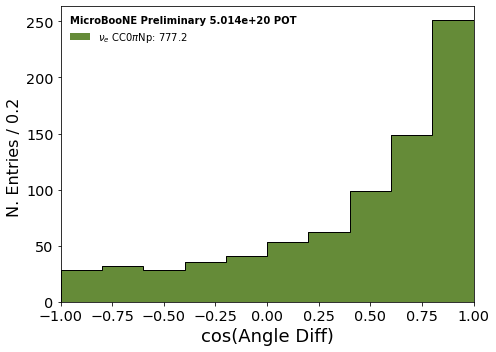

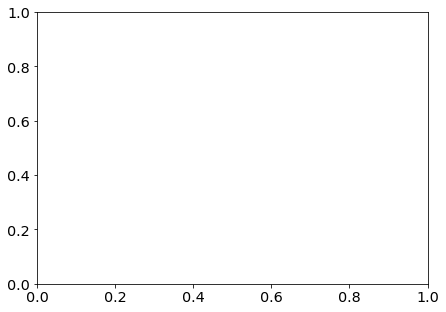

In [28]:
#TRUTH

import batch_plotter_alex
import importlib
importlib.reload(batch_plotter_alex)
scaling = 1

SPLIT = 1.0

n_events = numu_mc.shape[0]
print("n_events here = ", n_events)
print("")
batch_size = n_events

varss1 = []
weightss1 = []
labss1 = []

for i in range(int(n_events/batch_size)+1):
    start = i*batch_size
    if (start + batch_size) < n_events:
        end = start + batch_size
    else:
        end = n_events
    sample_set = numu_mc.iloc[start:end]

    samples = {
        "numu_mc": sample_set 
    }


    scaling = 1
    if isRun3 == False:
        pot =  2e+20 
        mcratio   = pot/2.33978e+21
    elif isRun3 == True:
        pot =  5.014e20
        mcratio  = pot/2.64408e+21

    weights = {
                "numu_mc"  : mcratio  * SPLIT * scaling
    }


    my_plotter = batch_plotter_alex.Plotter(samples, weights, pot=pot)
    
    VARIABLE, BINS, RANGE, XTIT = 'cosNu_Angle_Numi_Muon',10,(-1.0, 1.0),"cos(Angle Diff)"
    

    var, weight, label = my_plotter.plot_variable(
        VARIABLE,
        query= SIGNAL_NUMU_SEL_QUERY,
        currentsample = "numu_mc",
        kind="event_category",
        draw_sys  = True, 
        draw_geoSys = True, 
        draw_data = True,
        ratio=False,
        genieweight = "weightSplineTimesTuneTimesPPFX",  
        stacksort=3,
        title=XTIT,
        bins=BINS,
        range=RANGE
    )[0:3]
    
    varss1.append(var)
    weightss1.append(weight)
    labss1.append(label)

No handles with labels found to put in legend.


(array([ 28.2501859 ,  31.59143339,  28.0747649 ,  35.04770073,
        40.81482908,  53.3       ,  62.09478197,  98.41157396,
       148.79862569, 250.82818064]), array([-1. , -0.8, -0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ]), <a list of 10 Patch objects>)
(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([-1. , -0.8, -0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ]), <a list of 10 Patch objects>)


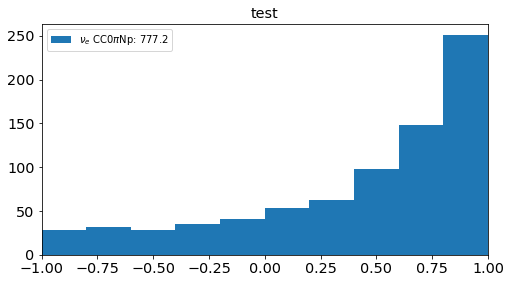

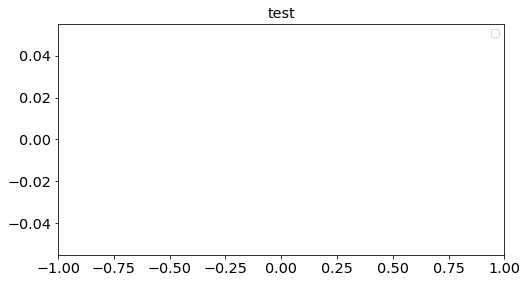

In [29]:
from matplotlib import gridspec

for i in range(int(n_events/batch_size)+1):
    numu_fig = plt.figure(figsize=(8, 7))
    numu_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
    numu_ax1 = plt.subplot(numu_gs[0])

    numu_stacked = numu_ax1.hist(
                varss1[i].values(),
                weights=list(weightss1[i].values()),
                stacked=True,
                label=labss1[i],
                bins=BINS,
                range=RANGE)
    
    plt.title("test")
    plt.legend()
    
    print(numu_stacked)

[ 28.2501859   31.59143339  28.0747649   35.04770073  40.81482908
  53.3         62.09478197  98.41157396 148.79862569 250.82818064]


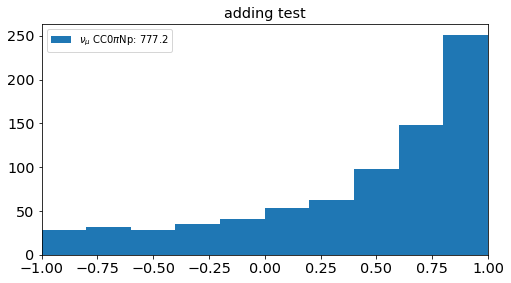

In [30]:
def mergeDictionary(dict_1, dict_2):
    dict_3 = {**dict_1, **dict_2}
    for key, value in dict_3.items():
        if key in dict_1 and key in dict_2:
                dict_3[key] = value + dict_1[key]
    return dict_3

def combine_dicts(mydict):
    while len(mydict) > 1:
        i = 0
        dict_3 = mergeDictionary(mydict[i], mydict[i+1]) 
        mydict.pop(0)
        mydict[0] = dict_3
    return mydict
    
varss_tot = combine_dicts(varss1)
weightss_tot = combine_dicts(weightss1)

category_labels = {
    1 : r'$\nu_\mu$ CC0$\pi$Np', 
    2 : r'Out FV',
    3 : r'$\nu_e$ CC $\pi^{0}$',
    4 : r'$\nu_e$ CC',
    5 : r'$\nu_e$ NC $\pi^{0}$',
    6 : r'$\nu_e$ NC',
    7 : r'$\bar{\nu}_\mu$ CC0$\pi$Np',
    8: r'$\nu_\mu$ NC',
    9: r'$\nu_\mu$ CC other',
    10 : r'$\nu_\mu$ / $\overline{\nu_\mu}$  other', 
    11 : r'$\nu_\mu$ / $\overline{\nu_e}$  $\pi^{0}$', 
    12 : r'$\nu_\mu$ / $\overline{\nu_e}$  other',
    0: r'Unknown'
}


labels = [
            "%s: %.1f" % (category_labels[c], sum(weightss_tot[0][c])) \
            if sum(weightss_tot[0][c]) else ""
            for c in varss1[0].keys()
        ]


numu_fig = plt.figure(figsize=(8, 7))
numu_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
numu_ax1 = plt.subplot(numu_gs[0])


numu_stacked = numu_ax1.hist(
            varss_tot[0].values(),
            weights=list(weightss_tot[0].values()),
            stacked=True,
            label=labels,
            bins=BINS,
            range=RANGE)

plt.title("adding test")
plt.legend()

print(numu_stacked[0])

temp_truth_sig = numu_stacked[0]

n_events here =  65866

1.0
1
{'numu_mc': 0.1896311760612387}
nslice == 1 and ( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1) and reco_nu_vtx_sce_x > 15 and reco_nu_vtx_sce_x < 245 and reco_nu_vtx_sce_y > -105 and reco_nu_vtx_sce_y < 105 and reco_nu_vtx_sce_z > 10 and reco_nu_vtx_sce_z < 990 and n_muons_tot > 0 and n_protons_tot > 0 and n_showers_contained==0 and contained_fraction> 0.95 and topological_score > 0.3and is_signal==True 
 ~(abs(nu_pdg)==12 and ccnc==0 and -1.55<=true_nu_vtx_x<=254.8 and -116.5<=true_nu_vtx_y<=116.5 and 0<=true_nu_vtx_z<=1036.8) 
 None 
 False 
 numu_mc
--------------------------------------
current_total  777.212076261981
777.212076261980996605416294187307357788085937500000000000000000000000000000000
---------------------------STILL TOGETHER HERE--------------------------------
current_total  777.212076261981
777.212076261980996605416294187307357788085937500000000000000000000000000000000
---------------------------STI

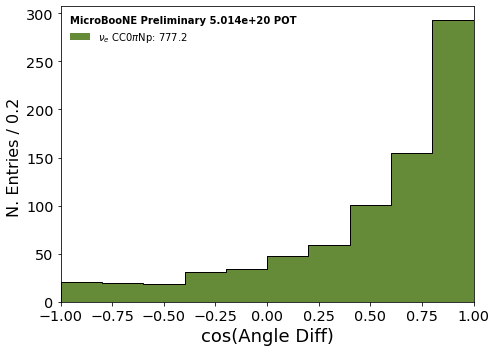

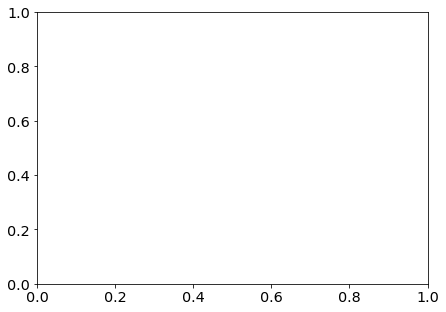

In [31]:
# NOW WITH RECO SELECTION

import batch_plotter_alex
import importlib
importlib.reload(batch_plotter_alex)
scaling = 1

SPLIT = 1.0

n_events = numu_mc.shape[0]
print("n_events here = ", n_events)
print("")
batch_size = n_events

varss2 = []
weightss2 = []
labss2 = []


for i in range(int(n_events/batch_size)+1):
    start = i*batch_size
    if (start + batch_size) < n_events:
        end = start + batch_size
    else:
        end = n_events
    sample_set = numu_mc.iloc[start:end]

    samples = {
        "numu_mc": sample_set 
    }


    scaling = 1
    if isRun3 == False:
        pot =  2e+20 
        mcratio   = pot/2.33978e+21
    elif isRun3 == True:
        pot =  5.014e20
        mcratio  = pot/2.64408e+21


    weights = {
                "numu_mc"  : mcratio  * SPLIT * scaling
    }


    my_plotter = batch_plotter_alex.Plotter(samples, weights, pot=pot)
    
    VARIABLE, BINS, RANGE, XTIT = 'cosNu_Angle_Numi_Muon_Reco',10,(-1.0, 1.0),"cos(Angle Diff)"
    

    var, weight, label = my_plotter.plot_variable(
        VARIABLE,
        query= SIGNAL_NUMU_SEL_QUERY,
        currentsample = "numu_mc",
        kind="event_category",
        draw_sys  = True, 
        draw_geoSys = True, 
        draw_data = True,
        ratio=False,
        genieweight = "weightSplineTimesTuneTimesPPFX",  
        stacksort=3,
        title=XTIT,
        bins=BINS,
        range=RANGE
    )[0:3]
    
    varss2.append(var)
    weightss2.append(weight)
    labss2.append(label)

No handles with labels found to put in legend.


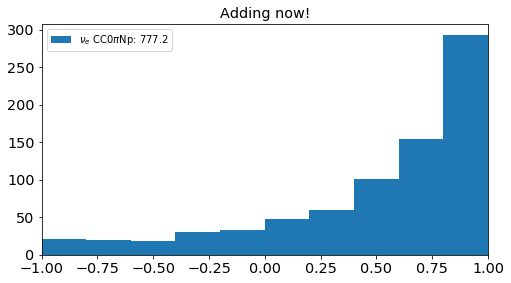

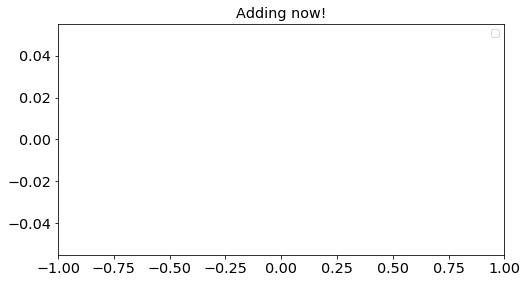

In [32]:
from matplotlib import gridspec

for i in range(int(n_events/batch_size)+1):
    numu_fig = plt.figure(figsize=(8, 7))
    numu_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
    numu_ax1 = plt.subplot(numu_gs[0])

    numu_stacked = numu_ax1.hist(
                varss2[i].values(),
                weights=list(weightss2[i].values()),
                stacked=True,
                label=labss2[i],
                bins=BINS,
                range=RANGE)
    
    plt.title("Adding now!")
    plt.legend()

In [7]:
# plot the smearing matrix 
def plot_smearing(var1, var2, weight1, weight2, var3, weight3, bins, norm=False): 
    fig = plt.figure(figsize=(10, 6))
    
    smear = plt.hist2d(var1, var2,
                   bins, weights=weight1, cmin=0.000000001, cmap='OrRd')
    
    sel1 = plt.hist(var1, bins, weights=weight1, color='white')
    print("sel1 = ", sel1[0])
    print("sum sel1 = ", math.fsum(sel1[0]))
    print("")
    sel2 = plt.hist(var2, bins, weights=weight2, color='white')
    print("sel2 = ", sel2[0])
    print("sum sel2 = ", math.fsum(sel2[0]))
    print("")
    print("truth - reco (sel1 - sel2) ")
    print(sel1[0] - sel2[0])
    print(math.fsum(sel1[0]) - math.fsum(sel2[0]))
    
    zero_copy_smear = np.copy(smear[0].T)
    
    for i in range(len(bins)-1): # reco bins i (y axis) rows
        for j in range(len(bins)-1): # true bins j (x axis) cols
            if np.isnan(zero_copy_smear[i,j]):
                zero_copy_smear[i,j]= 0

    for i in range(len(bins)-1): # reco bins i (y axis) rows
        for j in range(len(bins)-1): # true bins j (x axis) cols
            if smear[0].T[i,j] > 0: 
                if smear[0].T[i,j]>80: 
                    col='white'
                else: 
                    col='black'
                    
                binx_centers = smear[1][j]+(smear[1][j+1]-smear[1][j])/2
                biny_centers = smear[2][i]+(smear[2][i+1]-smear[2][i])/2
                        
                plt.text(binx_centers, biny_centers, round(smear[0].T[i,j], 1), 
                    color=col, ha="center", va="center", fontsize=12)

    cbar = plt.colorbar()
    cbar.set_label('Selected Signal Events', fontsize=15)
        
    print("---------------------------------------------------------")

    if norm: 
        plt.close()
        
        norm_array = smear[0].T
        
        gen = plt.hist(var3, bins, weights=weight3, color='deepskyblue')
        print("")
        print("GENERATED")
        print(gen[0])
        print("")
        plt.close()
    
        # for each truth bin (column): 
        for j in range(len(bins)-1): 
        
            # replace with normalized value 
            for i in range(len(bins)-1):
                norm_array[i][j] =  norm_array[i][j] / gen[0][j]
    
        # now plot
        fig = plt.figure(figsize=(10, 6))
        plt.pcolor(bins, bins, norm_array, cmap='OrRd', vmax=1)
        
        zero_copy_smear_norm = np.copy(norm_array)

        for i in range(len(bins)-1): # reco bins i (y axis) rows
            for j in range(len(bins)-1): # true bins j (x axis) cols
                if np.isnan(zero_copy_smear_norm[i,j]):
                    zero_copy_smear_norm[i,j]= 0

        # Loop over data dimensions and create text annotations.
        for i in range(len(bins)-1): # reco bins (rows)
            for j in range(len(bins)-1): # truth bins (cols)
                if norm_array[i][j]>0: 
                
                    if norm_array[i][j]>0.7: 
                        col = 'white'
                    else: 
                        col = 'black'
                    
                    binx_centers = smear[1][j]+(smear[1][j+1]-smear[1][j])/2
                    biny_centers = smear[2][i]+(smear[2][i+1]-smear[2][i])/2
                
                    plt.text(binx_centers, biny_centers, round(norm_array[i][j], 2), 
                         ha="center", va="center", color=col, fontsize=12)
      
        cbar = plt.colorbar()
        cbar.set_label('Fraction of Reco Events in True Bin', fontsize=15)
        
        
        if isRun3 == False and isCombined == False:
            np.savetxt("numu_full_500_catsel_nopions_angleDiff_usingSelection_smearcept_weighted_recoCut_"+ending+".csv", 
                zero_copy_smear_norm,
                delimiter =", ", 
                fmt ='% s')

            print("ZERO COPY SMEAR NORM")
            print(zero_copy_smear_norm)
        elif isRun3 == True and isCombined == False:
            np.savetxt("numu_full_500_catsel_nopions_angleDiff_usingSelection_smearcept_weighted_recoCut_run3_"+ending+".csv", 
                zero_copy_smear_norm,
                delimiter =", ", 
                fmt ='% s')

            print("ZERO COPY SMEAR NORM")
            print(zero_copy_smear_norm)

        elif isCombined == True:
            np.savetxt("numu_full_500_catsel_nopions_angleDiff_usingSelection_smearcept_weighted_recoCut_comb_"+ending+".csv", 
                zero_copy_smear_norm,
                delimiter =", ", 
                fmt ='% s')

            print("ZERO COPY SMEAR NORM")
            print(zero_copy_smear_norm)

    plt.xlabel('True ν Energy [GeV]', fontsize=15)
    plt.ylabel('Reco ν Energy [GeV]', fontsize=15)
    
    plt.show()
    fig.savefig("numu_full_500_catsel_nopions_angleDiff_usingSelection_smearcept_weighted_recoCut_comb_"+ending+".svg",bbox_inches='tight' )
    
    if norm:
        return zero_copy_smear_norm
    else:
        return zero_copy_smear

In [8]:
def _selection(variable, sample, query="selected==1", extra_cut=None, track_cuts=None, select_longest=True):
        '''
        variable,  must be specified
        select_longest, True by default, keeps from multiple tracks of same event making it through
        query must be a string defining event-level cuts
        track_cuts is a list of cuts of which each entry looks like
            (variable_tobe_cut_on, '>'or'<'or'=='etc, cut value )
            or
            (variable, [operator1, operator2], [cutval1, cutval2]) to do an 'or' cut
        track_
        returns an Series of values that pass all track_cuts
        '''
        sel_query = query
        if extra_cut is not None:
            sel_query += "& %s" % extra_cut

        df = sample.query(sel_query)

        track_cuts_mask = None #df['trk_score_v'].apply(lambda x: x == x) #all-True mask, assuming trk_score_v is available
        if track_cuts is not None:
            vars, track_cuts_mask = _apply_track_cuts(df,variable,track_cuts,track_cuts_mask)
        else:
            vars = df[variable]
        #vars is now a Series object that passes all the cuts
        #select longest of the cut passing tracks
        #assuming all track-level variables end in _v
        if variable[-2:] == "_v" and select_longest:
            vars, longest_mask = _select_longest(df, vars, track_cuts_mask)
        elif "_v_" in variable:
            print("Variable is being interpretted as event-level, not track_level, despite having _v in name")
            print("the longest track is NOT being selected")
        return vars.ravel()
    
#-------------------------------------------------------------------
def _apply_track_cuts(df,variable,track_cuts,mask):
    '''
    df is dataframe of the sample of interest
    variable is what values will be in the output
    track_cuts are list of tuples defining track_cuts
    input mask to be built upon

    returns
        Series of values of variable that pass all track_cuts
        boolean mask that represents union of input mask and new cut mask
    '''
    #need to do this fancy business with the apply function to make masks
    #this is because unflattened DataFrames are used
    for (var,op,val) in track_cuts:
        if type(op) == list:
            #this means treat two conditions in an 'or' fashion
            or_mask1 = df[var].apply(lambda x: eval("x{}{}".format(op[0],val[0])))#or condition 1
            or_mask2 = df[var].apply(lambda x: eval("x{}{}".format(op[1],val[1])))#or condition 2
            mask *= (or_mask1 + or_mask2) #just add the booleans for "or"
        else:
            mask *= df[var].apply(lambda x: eval("x{}{}".format(op,val))) #layer on each cut mask
    vars = (df[variable]*mask).apply(lambda x: x[x != False]) #apply mask
    vars = vars[vars.apply(lambda x: len(x) > 0)] #clean up empty slices
    #fix list comprehension issue for non '_v' variables
    if variable[-2:] != "_v":
        vars = vars.apply(lambda x: x[0])
    elif "_v" not in variable:
        print("_v not found in variable, assuming event-level")
        print("not fixing list comprehension bug for this variable")

    return vars, mask
    
#-----------------------------------------------------------------------

def _select_longest(df, variable, mask):
    '''
    df: dataframe for sample
    variable: Series of values that pass cuts defined by mask
    mask: mask used to find variable

    returns
        list of values of variable corresponding to longest track in each slices
        boolean mask for longest tracks in df
    '''
    trk_lens = (df['trk_len_v']*mask).apply(lambda x: x[x != False])#apply mask to track lengths
    trk_lens = trk_lens[trk_lens.apply(lambda x: len(x) > 0)]#clean up slices
    variable = variable.apply(lambda x: x[~np.isnan(x)])#clean up nan vals
    variable = variable[variable.apply(lambda x: len(x) > 0)] #clean up empty slices
    nan_mask = variable.apply(lambda x: np.nan in x or "nan" in x)
    longest_mask = trk_lens.apply(lambda x: x == x[list(x).index(max(x))])#identify longest
    variable = (variable*longest_mask).apply(lambda x: x[x!=False])#apply mask
    if len(variable.iloc[0]) == 1:
        variable = variable.apply(lambda x: x[0] if len(x)>0 else -999)#expect values, not lists, for each event
    else:
        if len(variable.iloc[0]) == 0:
            raise ValueError(
                "There is no longest track per slice")
        elif len(variable.iloc[0]) > 1:
            #this happens with the reco_nu_e_range_v with unreconstructed values
            print("there are more than one longest slice")
            print(variable.iloc[0])
            try:
                variable = variable.apply(lambda x: x[0])
            except:
                raise ValueError(
                    "There is more than one longest track per slice in \n var {} lens {}".format(variable,trk_lens))

    return variable, longest_mask
    
#-----------------------------------------------------------------------
def _get_genie_weight(sample, variable, query="selected==1", extra_cut=None, track_cuts=None,\
                          select_longest=True, weightvar="weightSplineTimesTuneTimesPPFX",weightsignal=None):

        plotted_variable = _selection(
            variable, sample, query=query, extra_cut=extra_cut, track_cuts=track_cuts, select_longest=select_longest)
        genie_weights = _selection(
            weightvar, sample, query=query, extra_cut=extra_cut, track_cuts=track_cuts, select_longest=select_longest)
        if (weightsignal != None):
            genie_weights *= _selection(
            weightsignal, sample, query=query, extra_cut=extra_cut, track_cuts=track_cuts, select_longest=select_longest)
        if plotted_variable.size > 0:
            if isinstance(plotted_variable[0], np.ndarray):
                if "trk" in variable or select_longest:
                    score = self._selection(
                        "trk_score_v", sample, query=query, extra_cut=extra_cut, track_cuts=track_cuts, select_longest=select_longest)
                else:
                    score = self._selection(
                        "shr_score_v", sample, query=query, extra_cut=extra_cut, track_cuts=track_cuts, select_longest=select_longest)
                genie_weights = np.array([
                    np.array([c] * len(v[s > 0.5])) for c, v, s in zip(genie_weights, plotted_variable, score)
                ])
                genie_weights = np.hstack(genie_weights)
        return genie_weights

n_events here =  65866
n_events/2 here =  32933.0

1.0
1
All is well.
sel1 =  [ 28.25018692  31.59143448  28.07476807  35.0476532   40.814888
  53.29994202  62.095047    98.4112854  148.79870605 250.82794189]
sum sel1 =  777.2118530273438

sel2 =  [ 20.61427498  19.79376411  18.95620728  30.51236343  33.60819244
  47.21565247  59.01167297 100.56521606 154.40103149 292.53390503]
sum sel2 =  777.2122802734375

truth - reco (sel1 - sel2) 
[  7.63591194  11.79767036   9.11856079   4.53528976   7.20669556
   6.08428955   3.08337402  -2.15393066  -5.60232544 -41.70596313]
-0.00042724609375
---------------------------------------------------------

GENERATED
[ 337.22372437  405.09451294  444.63977051  519.96496582  679.24230957
  792.78637695 1054.37207031 1468.24511719 2245.58642578 5939.875     ]

ZERO COPY SMEAR NORM
[[4.89103285e-02 6.57256236e-03 9.64299164e-04 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 4.15355978e-04
  0.00000000e+00 7.06124799e-05]
 [1.72519110e-03 4

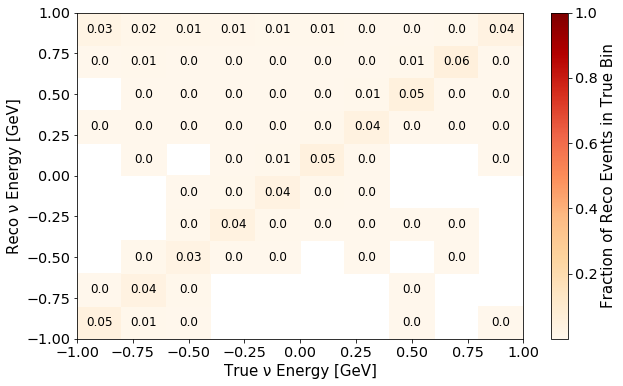

In [35]:
n_events = numu_mc.shape[0]
print("n_events here = ", n_events)
print("n_events/2 here = ", np.floor(n_events/2))
print("")
batch_size = n_events

varss = []
weightss = []
labss = []



start = 0*batch_size
if (start + batch_size) < n_events:
    end = start + batch_size
else:
    end = n_events
sample_set = numu_mc.iloc[start:end]


scaling = 1
if isRun3 == False:
    pot =  2e+20 
    mcratio   = pot/2.33978e+21
elif isRun3 == True:
    pot =  5.014e20
    mcratio  = pot/2.64408e+21

weights = {
            "numu_mc"  : mcratio  * SPLIT * scaling
}

current_genie_weights = _get_genie_weight(
                sample_set, 'cosNu_Angle_Numi_Muon', query=SIGNAL_NUMU_SEL_QUERY, track_cuts=None,select_longest=False, weightvar="weightSplineTimesTuneTimesPPFX")


current_genie_weights2 = _get_genie_weight(
                sample_set, 'cosNu_Angle_Numi_Muon_Reco', query=SIGNAL_NUMU_SEL_QUERY, track_cuts=None,select_longest=False, weightvar="weightSplineTimesTuneTimesPPFX")


current_genie_weights3 = _get_genie_weight(
                sample_set, 'cosNu_Angle_Numi_Muon', query=SIGNAL_ONLY_NUMU_SEL_QUERY, track_cuts=None,select_longest=False, weightvar="weightSplineTimesTuneTimesPPFX")

test_list1 = current_genie_weights
test_list2 = current_genie_weights2

if len(test_list1) == len(test_list2) and len(test_list1) == sum([1 for i, j in zip(test_list1, test_list2) if i == j]):
    print("All is well.")
else:
    print("Oh no.")

bins = np.arange(-1.0, 1.2, 0.2)


var1 = sample_set.query(SIGNAL_NUMU_SEL_QUERY)['cosNu_Angle_Numi_Muon']
weight1 = current_genie_weights * weights["numu_mc"]
if isRun3 == False and isCombined == False:
    var1.to_csv("numu_full_var1_recoCut_angleDiff_"+ending+".csv")
    np.savetxt("numu_full_weight1_recoCut_angleDiff_"+ending+".csv", 
                weight1,
                delimiter =", ", 
                fmt ='% s')
if isRun3 == True and isCombined == False:
    var1.to_csv("numu_full_var1_recoCut_run3_angleDiff_"+ending+".csv")
    np.savetxt("numu_full_weights1_recoCut_run3_angleDiff_"+ending+".csv", 
                weight1,
                delimiter =", ", 
                fmt ='% s')     

var2 = sample_set.query(SIGNAL_NUMU_SEL_QUERY)['cosNu_Angle_Numi_Muon_Reco']
weight2 = current_genie_weights2* weights["numu_mc"]
if isRun3 == False and isCombined == False:
    var2.to_csv("numu_full_var2_recoCut_angleDiff_"+ending+".csv")
    np.savetxt("numu_full_weight2_recoCut_angleDiff_"+ending+".csv", 
                weight2,
                delimiter =", ", 
                fmt ='% s')
if isRun3 == True and isCombined == False:
    var2.to_csv("numu_full_var2_recoCut_run3_angleDiff_"+ending+".csv")
    np.savetxt("numu_full_weights2_recoCut_run3_angleDiff_"+ending+".csv", 
                weight2,
                delimiter =", ", 
                fmt ='% s')

var3 = sample_set.query(SIGNAL_ONLY_NUMU_SEL_QUERY)['cosNu_Angle_Numi_Muon']
weight3 = current_genie_weights3* weights["numu_mc"]
if isRun3 == False and isCombined == False:
    var3.to_csv("numu_full_var3_recoCut_angleDiff_"+ending+".csv")
    np.savetxt("numu_full_weight3_recoCut_angleDiff_"+ending+".csv", 
                weight3,
                delimiter =", ", 
                fmt ='% s')
if isRun3 == True and isCombined == False:
    var3.to_csv("numu_full_var3_recoCut_run3_angleDiff_"+ending+".csv")
    np.savetxt("numu_full_weights3_recoCut_run3_angleDiff_"+ending+".csv", 
                weight3,
                delimiter =", ", 
                fmt ='% s')


zerocopysmear = plot_smearing(var1, var2, weight1, weight2, var3, weight3, bins, norm=True)

### Now look at Efficiency and Purity

In [5]:
def plot_signal_and_eff(var1, weight1, var2, weight2, bins, variable, xaxis, savetitle, savetitleplot): 
    
    # generated true signal events per bin 
    gen = plt.hist(var1, bins, weights=weight1, color='deepskyblue')
    plt.close()
    
    # plot selected signal events 
    fig, ax1 = plt.subplots(figsize=(4, 5))
    
    # compute efficiency
    sel = ax1.hist(var2, bins, weights=weight2, color='white')
    print("sel = ", sel[0])
    print("")
    print("gen = ", gen[0])
    eff = [ a/b for a, b in zip(sel[0], gen[0]) ]
    eff_err = []
    for i in range(len(eff)):
        eff_err.append(math.sqrt( (eff[i]*(1-eff[i]))/gen[0][i] ) )
        print("In bin", i, ", eff = ", eff[i], " with error = ", eff_err[i])
        
    eff_tot = sum(sel[0])/sum(gen[0])
    print("Total Eff")
    print(eff_tot)
        
    # compute bin centers 
    bc = 0.5*(sel[1][1:]+sel[1][:-1])
    x_err = []
    for i in range(len(sel[1])-1): 
        x_err.append((sel[1][i+1]-sel[1][i])/2)

    # plot efficiency
    ax1.errorbar(bc, eff, xerr=x_err, yerr=eff_err, fmt='o', color='orangered', ecolor='orangered', markersize=3) 
    ax1.set_ylim(0, 1)
    ax1.set_ylabel('Efficiency', fontsize=15)
    ax1.set_title("Efficiency")
    ax1.set_xlabel(xaxis)
    
    np.savetxt(savetitle,
           eff,
           delimiter =", ", 
           fmt ='% s')
    
    print("Plot title: ", savetitleplot)
    fig.savefig(savetitleplot,bbox_inches='tight' )

    plt.show()

In [37]:
bins = np.arange(-1.0, 1.2, 0.2)
scaling = 1
SPLIT = 1.0

if isRun3 == False:
    pot =  2e+20 
    mcratio   = pot/2.33978e+21
elif isRun3 == True:
    pot =  5.014e20
    mcratio  = pot/2.64408e+21

weights = {
            "numu_mc"  : mcratio  * SPLIT * scaling
}

current_genie_weights = _get_genie_weight(
                numu_mc, 'cosNu_Angle_Numi_Muon', query=SIGNAL_ONLY_NUMU_SEL_QUERY, track_cuts=None,select_longest=False, weightvar="weightSplineTimesTuneTimesPPFX")

current_genie_weights2 = _get_genie_weight(
                numu_mc, 'cosNu_Angle_Numi_Muon', query=SIGNAL_NUMU_SEL_QUERY, track_cuts=None,select_longest=False, weightvar="weightSplineTimesTuneTimesPPFX")


var1 = numu_mc.query(SIGNAL_ONLY_NUMU_SEL_QUERY)['cosNu_Angle_Numi_Muon']
weight1 = current_genie_weights* weights["numu_mc"]
if isRun3 == False and isCombined == False:
    var1.to_csv("numu_full_var1_eff_recoCut_angleDiff_"+ending+".csv")
    np.savetxt("numu_full_weight1_eff_recoCut_angleDiff_"+ending+".csv", 
                weight1,
                delimiter =", ", 
                fmt ='% s')
if isRun3 == True and isCombined == False:
    var1.to_csv("numu_full_var1_eff_recoCut_run3_angleDiff_"+ending+".csv")
    np.savetxt("numu_full_weights1_eff_recoCut_run3_angleDiff_"+ending+".csv", 
                weight1,
                delimiter =", ", 
                fmt ='% s') 

var2 = numu_mc.query(SIGNAL_NUMU_SEL_QUERY)['cosNu_Angle_Numi_Muon']
weight2 = current_genie_weights2 * weights["numu_mc"]
if isRun3 == False and isCombined == False:
    var2.to_csv("numu_full_var2_eff_recoCut_angleDiff_"+ending+".csv")
    np.savetxt("numu_full_weight2_eff_recoCut_angleDiff_"+ending+".csv", 
                weight2,
                delimiter =", ", 
                fmt ='% s')
if isRun3 == True and isCombined == False:
    var2.to_csv("numu_full_var2_eff_recoCut_run3_angleDiff_"+ending+".csv")
    np.savetxt("numu_full_weights2_eff_recoCut_run3_angleDiff_"+ending+".csv", 
                weight2,
                delimiter =", ", 
                fmt ='% s')


###########################################

variable = 'cosNu_Angle_Numi_Muon'
xaxis = "cos(True Lepton Angle)"
if isRun3 == False and isCombined == False:
    savetitle = "batch_eff_numu_fig_full_500_catsel_nopions_angleDiff_matrix_trueeff_"+ending+".csv"
if isRun3 == True and isCombined == False:
    savetitle = "batch_eff_numu_fig_full_500_catsel_nopions_angleDiff_matrix_trueeff_run3_"+ending+".csv"

### Combined Loading and Calculation

sel1 =  [ 39.02553935  41.41730865  41.43039915  50.80994832  60.31509801
  74.22836657  93.16333359 141.59336546 219.17043242 377.23471562]
sum sel1 =  1138.3885071427717

sel2 =  [ 28.99280881  26.20432053  28.18761158  42.97844349  50.75284738
  66.10113986  87.45204011 144.09852128 227.35084025 436.26993387]
sum sel2 =  1138.3885071427715

truth - reco (sel1 - sel2) 
[ 10.03273054  15.21298812  13.24278757   7.83150483   9.56225063
   8.12722672   5.71129348  -2.50515581  -8.18040783 -59.03521825]
2.2737367544323206e-13
---------------------------------------------------------

GENERATED
[ 521.21061414  612.45345854  665.23743195  792.67078832  994.84178998
 1185.83125433 1559.38283378 2176.63370068 3445.949611   9001.65856945]

ZERO COPY SMEAR NORM
[[4.38630322e-02 5.10801999e-03 7.60714687e-04 4.08226183e-04
  1.03403075e-04 1.26343876e-04 0.00000000e+00 2.80177776e-04
  4.00577680e-05 1.30230207e-04]
 [1.86574892e-03 3.62893509e-02 3.70857535e-03 1.20932664e-04
  0.00000000e+00 

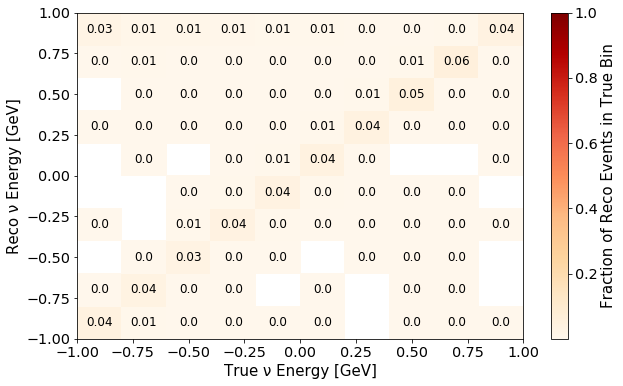

In [9]:
#####Smearing####
smearing_var1_run1 = pd.read_csv("numu_full_var1_recoCut_angleDiff_"+ending+".csv")

with open('numu_full_weight1_recoCut_angleDiff_'+ending+'.csv', 'r') as read_obj:
        csv_reader = csv.reader(read_obj)
        smearing_weight1_run1 = list(csv_reader)

for a in range(len(smearing_weight1_run1)):
    smearing_weight1_run1[a] = float(smearing_weight1_run1[a][0])
### 
smearing_var2_run1 = pd.read_csv("numu_full_var2_recoCut_angleDiff_"+ending+".csv")

with open('numu_full_weight2_recoCut_angleDiff_'+ending+'.csv', 'r') as read_obj:
        csv_reader = csv.reader(read_obj)
        smearing_weight2_run1 = list(csv_reader)

for a in range(len(smearing_weight2_run1)):
    smearing_weight2_run1[a] = float(smearing_weight2_run1[a][0])
### 
smearing_var3_run1 = pd.read_csv("numu_full_var3_recoCut_angleDiff_"+ending+".csv")

with open('numu_full_weight3_recoCut_angleDiff_'+ending+'.csv', 'r') as read_obj:
        csv_reader = csv.reader(read_obj)
        smearing_weight3_run1 = list(csv_reader)

for a in range(len(smearing_weight3_run1)):
    smearing_weight3_run1[a] = float(smearing_weight3_run1[a][0])
###---####
smearing_var1_run3 = pd.read_csv("numu_full_var1_recoCut_run3_angleDiff_"+ending+".csv")

with open('numu_full_weights1_recoCut_run3_angleDiff_'+ending+'.csv', 'r') as read_obj:
        csv_reader = csv.reader(read_obj)
        smearing_weight1_run3 = list(csv_reader)

for a in range(len(smearing_weight1_run3)):
    smearing_weight1_run3[a] = float(smearing_weight1_run3[a][0])
### 
smearing_var2_run3 = pd.read_csv("numu_full_var2_recoCut_run3_angleDiff_"+ending+".csv")

with open('numu_full_weights2_recoCut_run3_angleDiff_'+ending+'.csv', 'r') as read_obj:
        csv_reader = csv.reader(read_obj)
        smearing_weight2_run3 = list(csv_reader)

for a in range(len(smearing_weight2_run3)):
    smearing_weight2_run3[a] = float(smearing_weight2_run3[a][0])
### 
smearing_var3_run3 = pd.read_csv("numu_full_var3_recoCut_run3_angleDiff_"+ending+".csv")

with open('numu_full_weights3_recoCut_run3_angleDiff_'+ending+'.csv', 'r') as read_obj:
        csv_reader = csv.reader(read_obj)
        smearing_weight3_run3 = list(csv_reader)

for a in range(len(smearing_weight3_run3)):
    smearing_weight3_run3[a] = float(smearing_weight3_run3[a][0])
    
####################Add#####################

var_temps = [smearing_var1_run1, smearing_var1_run3]
var1 = pd.concat(var_temps)
var1 = var1.drop(["entry"], axis=1)
var1 = var1.squeeze()
weight1 = list(smearing_weight1_run1) + list(smearing_weight1_run3)
weight1 = np.array(weight1)

var_temps = [smearing_var2_run1, smearing_var2_run3]
var2 = pd.concat(var_temps)
var2 = var2.drop(["entry"], axis=1)
var2 = var2.squeeze()
weight2 = list(smearing_weight2_run1) + list(smearing_weight2_run3)
weight2 = np.array(weight2)

var_temps = [smearing_var3_run1, smearing_var3_run3]
var3 = pd.concat(var_temps)
var3 = var3.drop(["entry"], axis=1)
var3 = var3.squeeze()
weight3 = list(smearing_weight3_run1) + list(smearing_weight3_run3)
weight3 = np.array(weight3)

bins = np.arange(-1.0, 1.2, 0.2)

zerocopysmear = plot_smearing(var1, var2, weight1, weight2, var3, weight3, bins, norm=True)

<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>
sel =  [ 39.02553935  41.41730865  41.43039915  50.80994832  60.31509801
  74.22836657  93.16333359 141.59336546 219.17043242 377.23471562]

gen =  [ 521.21061414  612.45345854  665.23743195  792.67078832  994.84178998
 1185.83125433 1559.38283378 2176.63370068 3445.949611   9001.65856945]
In bin 0 , eff =  0.07487479781631254  with error =  0.011528198922918613
In bin 1 , eff =  0.0676252343255466  with error =  0.010146426209057516
In bin 2 , eff =  0.06227911593027961  with error =  0.009369570309075714
In bin 3 , eff =  0.0640996856059306  with error =  0.008699540602691952
In bin 4 , eff =  0.060627829085951115  with error =  0.007566200465507908
In bin 5 , eff =  0.06259606187637191  with error =  0.007034373857175861
In bin 6 , eff =  0.059743721408218  with error =  0.006001957033421297
In bin 7 , eff =  0.06505153596484131  with error =  0.0052860338441285005
In bin 8 , eff =  0.06360233235023843  with error =  0.0041

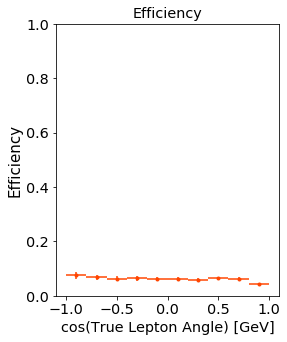

In [10]:
#####Efficiency####
smearing_var1_run1 = pd.read_csv("numu_full_var1_eff_recoCut_angleDiff_"+ending+".csv")

with open('numu_full_weight1_eff_recoCut_angleDiff_'+ending+'.csv', 'r') as read_obj:
        csv_reader = csv.reader(read_obj)
        smearing_weight1_run1 = list(csv_reader)

for a in range(len(smearing_weight1_run1)):
    smearing_weight1_run1[a] = float(smearing_weight1_run1[a][0])
### 
smearing_var2_run1 = pd.read_csv("numu_full_var2_eff_recoCut_angleDiff_"+ending+".csv")

with open('numu_full_weight2_eff_recoCut_angleDiff_'+ending+'.csv', 'r') as read_obj:
        csv_reader = csv.reader(read_obj)
        smearing_weight2_run1 = list(csv_reader)

for a in range(len(smearing_weight2_run1)):
    smearing_weight2_run1[a] = float(smearing_weight2_run1[a][0])
###---####
smearing_var1_run3 = pd.read_csv("numu_full_var1_eff_recoCut_run3_angleDiff_"+ending+".csv")

with open('numu_full_weights1_eff_recoCut_run3_angleDiff_'+ending+'.csv', 'r') as read_obj:
        csv_reader = csv.reader(read_obj)
        smearing_weight1_run3 = list(csv_reader)

for a in range(len(smearing_weight1_run3)):
    smearing_weight1_run3[a] = float(smearing_weight1_run3[a][0])
### 
smearing_var2_run3 = pd.read_csv("numu_full_var2_eff_recoCut_run3_angleDiff_"+ending+".csv")

with open('numu_full_weights2_eff_recoCut_run3_angleDiff_'+ending+'.csv', 'r') as read_obj:
        csv_reader = csv.reader(read_obj)
        smearing_weight2_run3 = list(csv_reader)

for a in range(len(smearing_weight2_run3)):
    smearing_weight2_run3[a] = float(smearing_weight2_run3[a][0])
    
####################Add#####################

var_temps = [smearing_var1_run1, smearing_var1_run3]
var1 = pd.concat(var_temps)
var1 = var1.drop(["entry"], axis=1)
var1 = var1.squeeze()
weight1 = list(smearing_weight1_run1) + list(smearing_weight1_run3)
weight1 = np.array(weight1)

var_temps = [smearing_var2_run1, smearing_var2_run3]
var2 = pd.concat(var_temps)
var2 = var2.drop(["entry"], axis=1)
var2 = var2.squeeze()
weight2 = list(smearing_weight2_run1) + list(smearing_weight2_run3)
weight2 = np.array(weight2)


bins = np.arange(-1.0, 1.2, 0.2)

variable = 'cosNu_Angle_Numi_Muon'
xaxis = "cos(True Lepton Angle) [GeV]"
isCombined = True
if isCombined == True:
    savetitle = "batch_eff_numu_fig_full_500_catsel_nopions_angleDiff_matrix_trueeff_comb_"+ending+".csv"
    savetitleplot = "batch_eff_numu_fig_full_500_catsel_nopions_angleDiff_matrix_trueeff_"+ending+".svg"

plot_signal_and_eff(var1, weight1, var2, weight2, bins, variable, xaxis, savetitle, savetitleplot)

In [1]:
##########################################################0.054440343300731206